# Klasyfikacja obrazów CIFAR-10 - CNN

Projekt: Sieć konwolucyjna do klasyfikacji obrazów

Wykonał: Michał Wawrentowicz

Grupa B – CNN

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from src.data import load_data
from src.model import CNN
from src.train import train_model
from src.evaluate import generate_report
from src.visualize import plot_history, plot_confusion_matrix


# 1. Wstęp

Celem projektu jest implementacja konwolucyjnej sieci neuronowej (CNN) do klasyfikacji obrazów ze zbioru CIFAR-10.

CIFAR-10 zawiera 60 000 obrazów w 10 klasach:

- samolot, 
- samochód, 
- ptak, 
- kot, 
- jeleń, 
- pies, 
- żaba, 
- koń, 
- statek, 
- ciężarówka

Każdy obraz ma rozmiar 32x32 piksele i 3 kanały RGB.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0026315749..1.0316222].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.12571564..1.0147774].


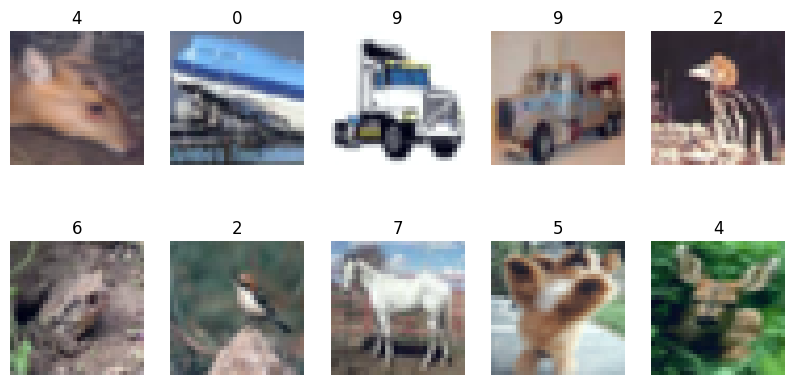

In [2]:
from src.data import load_data
import matplotlib.pyplot as plt

train_loader, test_loader, train_dataset, test_dataset = load_data(batch_size=64)

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(10,5))

for i, ax in enumerate(axes.flat):
    img = images[i].permute(1,2,0)
    img = img * 0.25 + 0.5
    ax.imshow(img)
    ax.set_title(str(labels[i].item()))
    ax.axis("off")

plt.show()

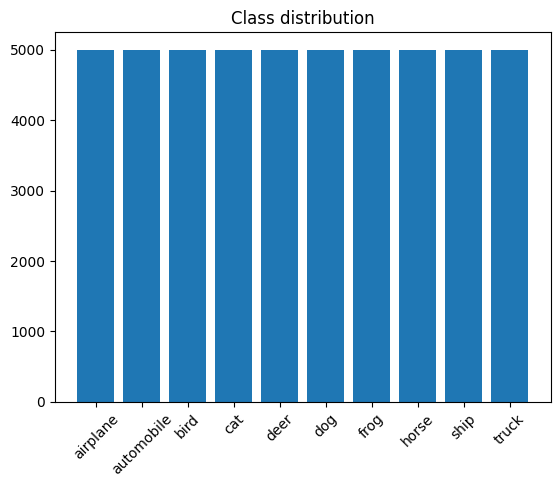

In [3]:
from collections import Counter

counts = Counter(train_dataset.targets)

plt.bar(train_dataset.classes, [counts[i] for i in range(10)])
plt.xticks(rotation=45)
plt.title("Class distribution")
plt.show()

In [4]:
images, labels = next(iter(train_loader))

print(images.shape)
print(images.min().item())
print(images.max().item())

torch.Size([64, 3, 32, 32])
-1.9894737005233765
2.12648868560791


# 2. Analiza zbioru danych

Zbiór CIFAR-10 zawiera:
- 50 000 obrazów treningowych
- 10 000 obrazów testowych

Obrazy są kolorowe w palecie RGB o wymiarach 32x32 piksele.
Każda próbka należy do jednej z 10 klas.

# Hiperparametry

- optimizer: Adam
- learning rate: 0.001
- batch size: 64
- epochs: 10

In [5]:
import torch
from src.model import CNN

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN(kernel_size=3, pooling="max").to(device)

model

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)

# 3. Architektura sieci

Zastosowano konwolucyjną sieć neuronową (CNN) składającą się z:

- 2 warstw konwolucyjnych (Conv2D)
- funkcji aktywacji ReLU
- warstw pooling (MaxPooling)
- warstwy w pełni połączonej (fully connected)
- warstwy Dropout (redukcja przeuczenia)

Conv2D wykrywa cechy obrazów.
ReLU dodaje nieliniowość.
Pooling zmniejsza rozmiar map cech.
Dropout ogranicza overfitting.
Fully Connected wykonuje klasyfikację.

Sieć przetwarza obraz i zamienia go na wektor cech, który następnie klasyfikuje do jednej z 10 klas.

In [6]:
import torch.nn as nn
import torch.optim as optim
from src.train import train_model

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

history = train_model(
    model,
    train_loader,
    test_loader,
    criterion,
    optimizer,
    device,
    epochs=5
)

Epoch 1/5 | Train Acc: 50.46% | Test Acc: 60.99%
Epoch 2/5 | Train Acc: 64.51% | Test Acc: 66.57%
Epoch 3/5 | Train Acc: 69.81% | Test Acc: 70.11%
Epoch 4/5 | Train Acc: 73.66% | Test Acc: 71.80%
Epoch 5/5 | Train Acc: 76.42% | Test Acc: 72.58%


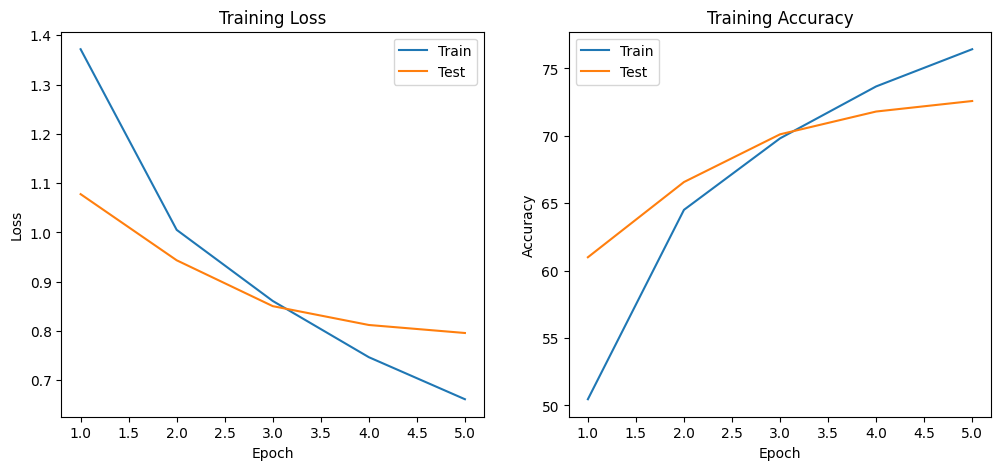

In [7]:
from src.visualize import plot_history

plot_history(history)

In [8]:
from src.evaluate import generate_report

classes = [
    "plane","car","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]

cm, report = generate_report(model, test_loader, classes, device)

print(report)

              precision    recall  f1-score   support

       plane       0.83      0.70      0.76      1000
         car       0.87      0.79      0.83      1000
        bird       0.61      0.62      0.62      1000
         cat       0.54      0.56      0.55      1000
        deer       0.69      0.69      0.69      1000
         dog       0.62      0.64      0.63      1000
        frog       0.77      0.83      0.80      1000
       horse       0.83      0.72      0.77      1000
        ship       0.74      0.90      0.81      1000
       truck       0.80      0.80      0.80      1000

    accuracy                           0.73     10000
   macro avg       0.73      0.73      0.73     10000
weighted avg       0.73      0.73      0.73     10000



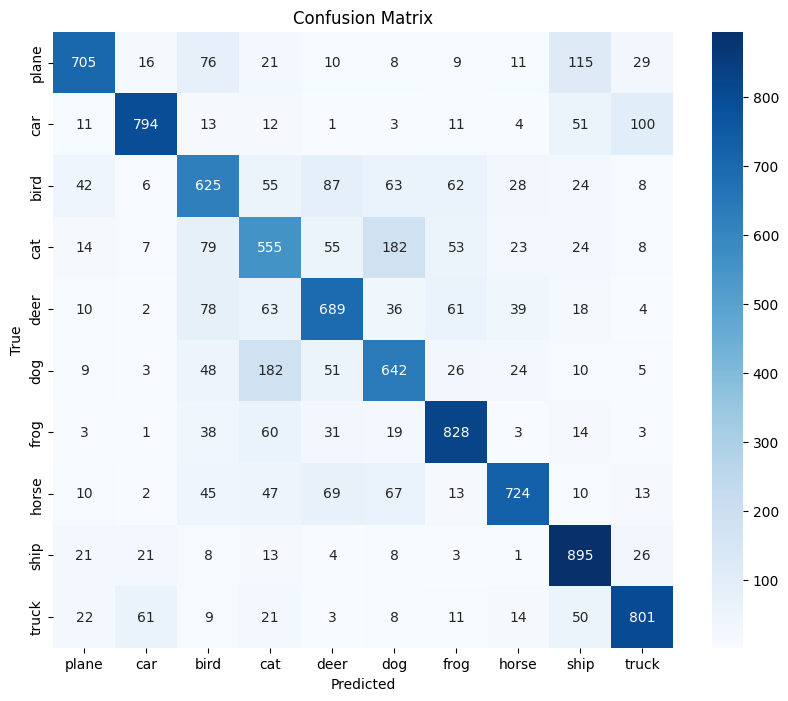

In [9]:
from src.visualize import plot_confusion_matrix

plot_confusion_matrix(cm, classes)

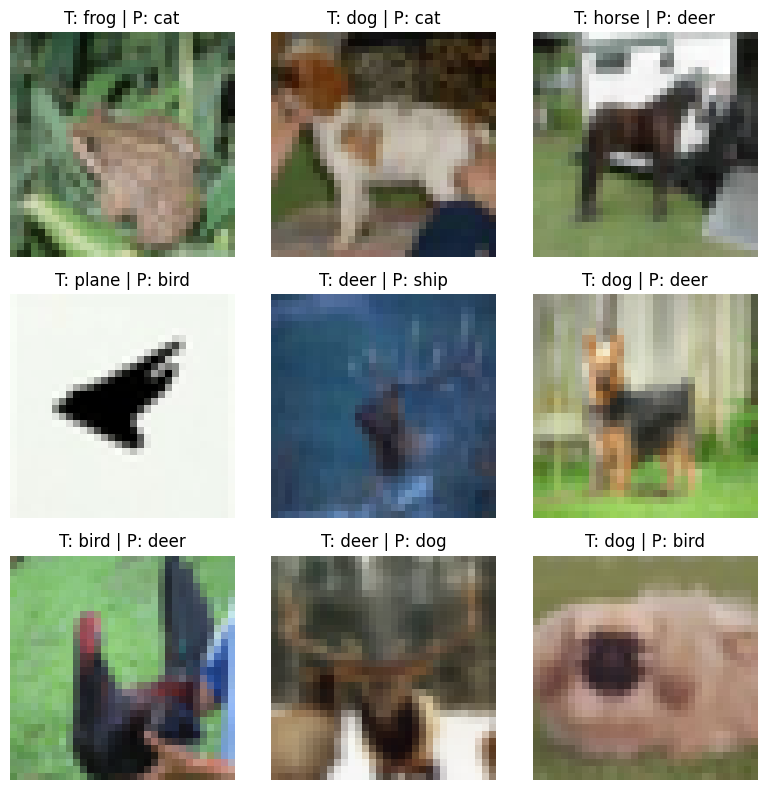

In [10]:
model.eval()

wrong = []

# wartości do odnormalizowania obrazów CIFAR-10
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        for j in range(len(labels)):
            if preds[j] != labels[j]:
                wrong.append((images[j].cpu(), labels[j].cpu().item(), preds[j].cpu().item()))

            if len(wrong) == 9:
                break

        if len(wrong) == 9:
            break

fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for ax, (img, true, pred) in zip(axes.flatten(), wrong):
    img = img * std + mean
    img = img.clamp(0, 1).permute(1, 2, 0).numpy()

    ax.imshow(img)
    ax.set_title(f"T: {classes[true]} | P: {classes[pred]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# 4. Eksperymenty

Wpływ rozmiaru kernela:

Sprawdzono wpływ rozmiaru filtra konwolucyjnego:
- kernel = 3
- kernel = 5
- kernel = 7

Zmiana rozmiaru wpływa na ilość informacji widzianych przez filtr.

In [1]:
from src.experiments import kernel_size_experiments

kernel_results = kernel_size_experiments(epochs=3)
kernel_results

Epoch 1/3 | Train Acc: 51.09% | Test Acc: 63.49%
Epoch 2/3 | Train Acc: 65.40% | Test Acc: 68.85%
Epoch 3/3 | Train Acc: 70.75% | Test Acc: 70.77%
Epoch 1/3 | Train Acc: 50.13% | Test Acc: 60.89%
Epoch 2/3 | Train Acc: 63.74% | Test Acc: 67.22%
Epoch 3/3 | Train Acc: 69.37% | Test Acc: 69.99%
Epoch 1/3 | Train Acc: 47.50% | Test Acc: 57.61%
Epoch 2/3 | Train Acc: 60.61% | Test Acc: 63.02%
Epoch 3/3 | Train Acc: 67.00% | Test Acc: 66.72%


[{'kernel_size': 3,
  'accuracy': 70.77,
  'history': {'train_loss': [1.362591319529297,
    0.9777284689114222,
    0.8319572409248108],
   'train_acc': [51.092, 65.404, 70.75],
   'test_loss': [1.0185264409727353, 0.889266632924414, 0.831929460072973],
   'test_acc': [63.49, 68.85, 70.77]}},
 {'kernel_size': 5,
  'accuracy': 69.99,
  'history': {'train_loss': [1.3927086853157833,
    1.0263805747641932,
    0.8748286677824567],
   'train_acc': [50.126, 63.744, 69.37],
   'test_loss': [1.104874971565927, 0.9315398806219648, 0.8594851091409185],
   'test_acc': [60.89, 67.22, 69.99]}},
 {'kernel_size': 7,
  'accuracy': 66.72,
  'history': {'train_loss': [1.456098866813323,
    1.1125182934734217,
    0.9454504144008812],
   'train_acc': [47.5, 60.608, 66.996],
   'test_loss': [1.1656370686877304, 1.0573676729657848, 0.9405507209953988],
   'test_acc': [57.61, 63.02, 66.72]}}]

In [2]:
import pandas as pd

kernel_df = pd.DataFrame([
    {"kernel_size": r["kernel_size"], "best_accuracy": r["accuracy"]}
    for r in kernel_results
])
kernel_df

,kernel_size,best_accuracy
0,3,70.77
1,5,69.99
2,7,66.72


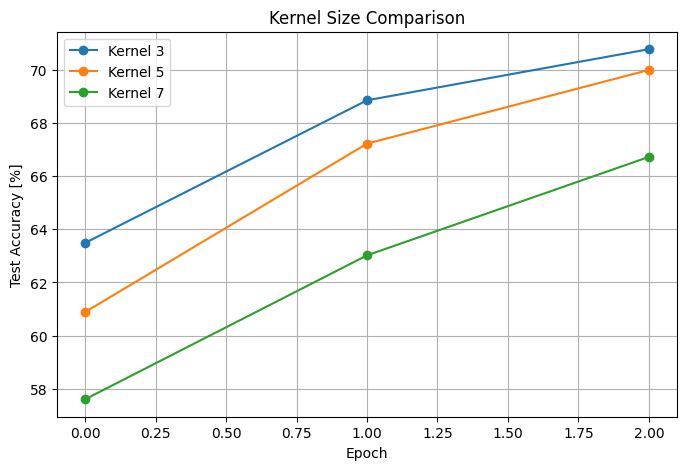

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for result in kernel_results:
    plt.plot(
        result["history"]["test_acc"],
        marker="o",
        label=f"Kernel {result['kernel_size']}"
    )

plt.title("Kernel Size Comparison")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy [%]")
plt.legend()
plt.grid(True)
plt.show()

# Wnioski
Kernel 3 dawał najlepsze wyniki. Dzieje się tak, bo mniejsze filtry lepiej wychwytują szczegóły.  
Większe kernele powodowały spadek dokładności, ponieważ model tracił szczegóły.

In [4]:
from src.experiments import pooling_experiments

pool_results = pooling_experiments(epochs=3)
pool_results

Epoch 1/3 | Train Acc: 50.89% | Test Acc: 63.54%
Epoch 2/3 | Train Acc: 64.58% | Test Acc: 68.10%
Epoch 3/3 | Train Acc: 69.82% | Test Acc: 70.39%
Epoch 1/3 | Train Acc: 49.77% | Test Acc: 60.16%
Epoch 2/3 | Train Acc: 62.74% | Test Acc: 66.63%
Epoch 3/3 | Train Acc: 68.62% | Test Acc: 70.00%
Epoch 1/3 | Train Acc: 45.76% | Test Acc: 56.75%
Epoch 2/3 | Train Acc: 62.84% | Test Acc: 65.55%
Epoch 3/3 | Train Acc: 72.76% | Test Acc: 66.07%


[{'pooling': 'max',
  'accuracy': 70.39,
  'history': {'train_loss': [1.368816782294027,
    1.0034895098727683,
    0.8527962979300857],
   'train_acc': [50.886, 64.582, 69.818],
   'test_loss': [1.044785103600496, 0.9025490097938829, 0.8409639931028816],
   'test_acc': [63.54, 68.1, 70.39]}},
 {'pooling': 'avg',
  'accuracy': 70.0,
  'history': {'train_loss': [1.4038821487018214,
    1.054904784235503,
    0.8922152226538305],
   'train_acc': [49.772, 62.74, 68.622],
   'test_loss': [1.1251359688248603, 0.9632706585203766, 0.867272073296225],
   'test_acc': [60.16, 66.63, 70.0]}},
 {'pooling': 'none',
  'accuracy': 66.07,
  'history': {'train_loss': [1.5043038840184126,
    1.0472335360391671,
    0.773027410059024],
   'train_acc': [45.756, 62.836, 72.756],
   'test_loss': [1.2013231124847559, 0.978860401044226, 0.9947774687390418],
   'test_acc': [56.75, 65.55, 66.07]}}]

In [5]:
pool_df = pd.DataFrame([
    {"pooling": r["pooling"], "best_accuracy": r["accuracy"]}
    for r in pool_results
])
pool_df

,pooling,best_accuracy
0,max,70.39
1,avg,70.00
2,none,66.07


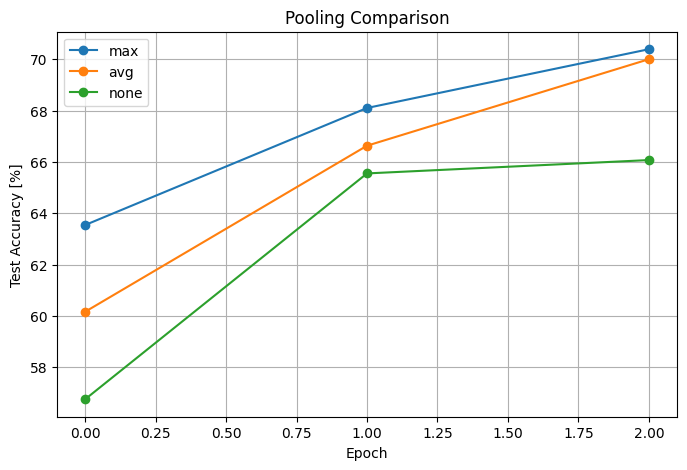

In [6]:
plt.figure(figsize=(8, 5))

for result in pool_results:
    plt.plot(
        result["history"]["test_acc"],
        marker="o",
        label=result["pooling"]
    )

plt.title("Pooling Comparison")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy [%]")
plt.legend()
plt.grid(True)
plt.show()

# Wnioski
MaxPooling osiągnął najlepsze accuracy.  
Avg pooling pozwala zmniejszyć liczbę parametrów oraz zachować najważniejsze cechy obrazu.  
Brak poolingu pogarszał generalizację.

In [11]:
from src.model import CNN
from src.train import train_model
from src.data import load_data

import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_loader, test_loader, train_dataset, test_dataset = load_data(batch_size=64)

lrs = [0.01, 0.001, 0.0001]
lr_results = []

for lr in lrs:
    model_lr = CNN(kernel_size=3, pooling="max").to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model_lr.parameters(), lr=lr)

    history_lr = train_model(
        model_lr,
        train_loader,
        test_loader,
        criterion,
        optimizer,
        device,
        epochs=3
    )

    lr_results.append({
        "lr": lr,
        "history": history_lr,
        "accuracy": max(history_lr["test_acc"])
    })

lr_results

Epoch 1/3 | Train Acc: 9.82% | Test Acc: 10.00%
Epoch 2/3 | Train Acc: 9.98% | Test Acc: 10.00%
Epoch 3/3 | Train Acc: 9.77% | Test Acc: 10.00%
Epoch 1/3 | Train Acc: 52.64% | Test Acc: 64.56%
Epoch 2/3 | Train Acc: 66.17% | Test Acc: 68.26%
Epoch 3/3 | Train Acc: 71.83% | Test Acc: 71.03%
Epoch 1/3 | Train Acc: 41.24% | Test Acc: 50.91%
Epoch 2/3 | Train Acc: 52.19% | Test Acc: 54.37%
Epoch 3/3 | Train Acc: 56.26% | Test Acc: 59.02%


[{'lr': 0.01,
  'history': {'train_loss': [2.3181180923491183,
    2.303553561725275,
    2.3035480076699613],
   'train_acc': [9.818, 9.976, 9.768],
   'test_loss': [2.303269981578657, 2.3037760789227333, 2.3040252961930197],
   'test_acc': [10.0, 10.0, 10.0]},
  'accuracy': 10.0},
 {'lr': 0.001,
  'history': {'train_loss': [1.3242613403388606,
    0.9598484870875278,
    0.8021242110549337],
   'train_acc': [52.64, 66.168, 71.826],
   'test_loss': [1.0150485202005715, 0.907840490720834, 0.8325490298544526],
   'test_acc': [64.56, 68.26, 71.03]},
  'accuracy': 71.03},
 {'lr': 0.0001,
  'history': {'train_loss': [1.6432494527238715,
    1.3477633890441008,
    1.2298850032984447],
   'train_acc': [41.242, 52.188, 56.26],
   'test_loss': [1.3871194754436518, 1.2607859741350649, 1.1610855319697386],
   'test_acc': [50.91, 54.37, 59.02]},
  'accuracy': 59.02}]

In [12]:
lr_df = pd.DataFrame([
    {"learning_rate": r["lr"], "best_accuracy": r["accuracy"]}
    for r in lr_results
])
lr_df

,learning_rate,best_accuracy
0,0.0100,10.00
1,0.0010,71.03
2,0.0001,59.02


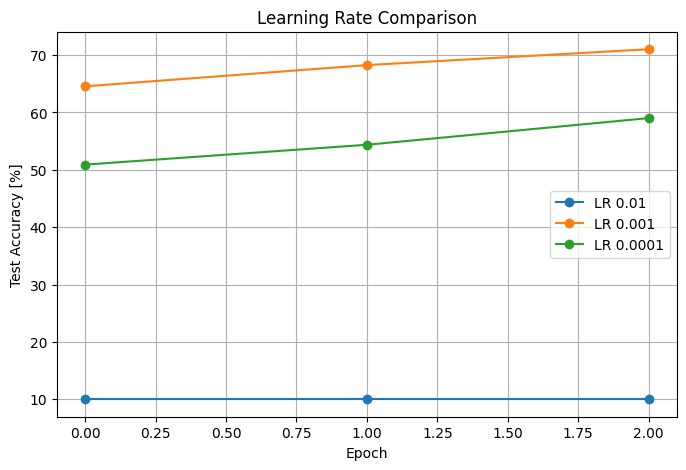

In [13]:
plt.figure(figsize=(8, 5))

for result in lr_results:
    plt.plot(
        result["history"]["test_acc"],
        marker="o",
        label=f"LR {result['lr']}"
    )

plt.title("Learning Rate Comparison")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy [%]")
plt.legend()
plt.grid(True)
plt.show()

# Wnioski

Learning rate 0.001 dawał najbardziej stabilny proces uczenia i najlepsze wyniki accuracy.  
Zbyt mały learning rate powodował bardzo wolne uczenie modelu, natomiast zbyt duży prowadził do niestabilnych wyników.